In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

def find_project_root(start=None):
    # Resolve the repository root automatically so nobody has to edit a hardcoded path.
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found")

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loading import load_csv_files, build_image_path
from src.preprocessing import split_train_validation, get_train_transforms, get_eval_transforms, ImageClassificationDataset
from src.baseline_cnn import BaselineCNN
from src.training import get_device, fit

In [2]:
# Loading data and preparing dataloaders.
# Loading training data, splitting into train/validation 80/20, and creating image datasets with transforms.
train_df, _ = load_csv_files()
train_split_df, val_split_df = split_train_validation(train_df, val_size=0.2, seed=42)

train_transform = get_train_transforms(32)
val_transform = get_eval_transforms(32)

train_paths = [build_image_path(row.Id, split='train', label=row.Category) for row in train_split_df.itertuples(index=False)]
val_paths = [build_image_path(row.Id, split='train', label=row.Category) for row in val_split_df.itertuples(index=False)]

train_dataset = ImageClassificationDataset(train_paths, train_split_df['Category'].tolist(), transform=train_transform)
val_dataset = ImageClassificationDataset(val_paths, val_split_df['Category'].tolist(), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print('train batches:', len(train_loader))
print('val batches:', len(val_loader))

train batches: 213
val batches: 54


In [3]:
# Initializing the model, the loss function and the optimizer.
device = get_device()
model = BaselineCNN(num_classes=10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print('device:', device)

device: mps


Epoch 01: train loss 0.3573 acc 0.8928: val loss 0.0459 acc 0.9876
Epoch 02: train loss 0.0735 acc 0.9788: val loss 0.0369 acc 0.9878
Epoch 03: train loss 0.0510 acc 0.9842: val loss 0.0201 acc 0.9968


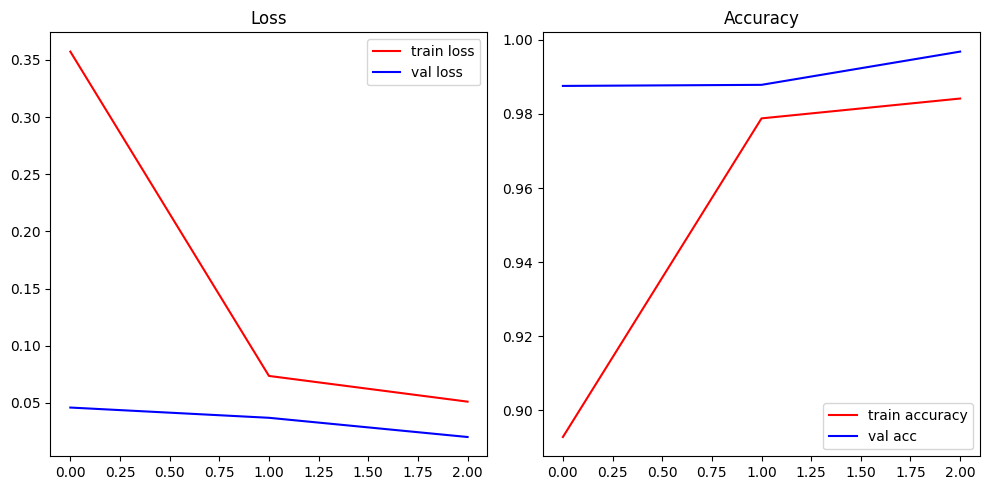

saved training curves to: /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/training_curves.png


In [4]:
# Training the model for 3 epochs and tracking loss and accuracy on both train and validation sets.
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=3,
)

# Plotting training and validation loss and accuracy curves to visualize model performance.
from pathlib import Path

OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
PLOT_PATH = OUTPUT_DIR / 'training_curves.png'

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].plot(history['train_loss'], label='train loss', color='red')
axes[0].plot(history['val_loss'], label='val loss', color='blue')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_accuracy'], label='train accuracy', color='red')
axes[1].plot(history['val_accuracy'], label='val acc', color='blue')
axes[1].set_title('Accuracy')
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print('saved training curves to:', PLOT_PATH)

In [5]:
# Saving the trained model and printing final training results.
from pathlib import Path

OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_PATH = OUTPUT_DIR / 'baseline_cnn.pt'

torch.save(model.state_dict(), MODEL_PATH)
print('saved model to:', MODEL_PATH)
print('final train accuracy:', history['train_accuracy'][-1])
print('final val accuracy:', history['val_accuracy'][-1])

saved model to: /Users/Valeria/Desktop/Image_Video_Processing_Project_Group_17/outputs/baseline_cnn.pt
final train accuracy: 0.9841549295774648
final val accuracy: 0.9968171296296297
